### Import statements

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.formula.api import ols
import pandas as pd

## Sensor calibration

### Subcritical sensor calibration curve

b0 = 36.867167582476284
b1 = 2.2729171352478246


Text(0, 0.5, 'Water level (cm)')

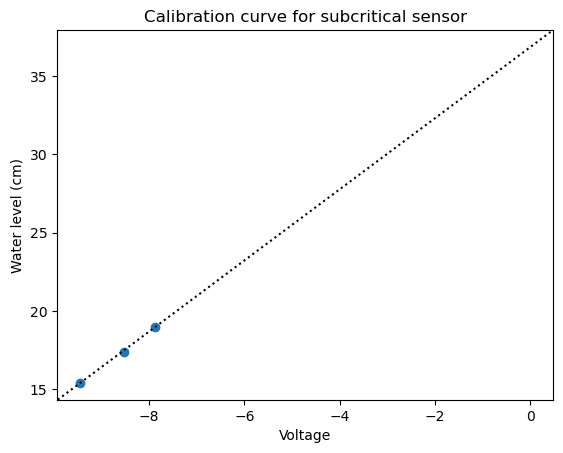

In [27]:
# calibration data
sub_voltage = np.array([-9.4592, -8.5297, -7.8816])
sub_height = np.array([15.4, 17.4, 19])                     # cm
sub_df = pd.DataFrame({'Voltage':sub_voltage, 'Height':sub_height})

# linear fit
sub_calibration = ols('Height ~ Voltage', data=sub_df).fit()
sub_b0, sub_b1 = sub_calibration.params
print(f'b0 = {sub_b0}')
print(f'b1 = {sub_b1}')

# plot
plt.scatter(sub_voltage, sub_height)
plt.axline(xy1=(0,sub_b0), slope=sub_b1, color='black', linestyle=':')
plt.title('Calibration curve for subcritical sensor')
plt.xlabel('Voltage')
plt.ylabel('Water level (cm)')

### Supercritical sensor calibration curve

b0 = 28.6137223023922
b1 = 2.2998132138163467


Text(0, 0.5, 'Water level (cm)')

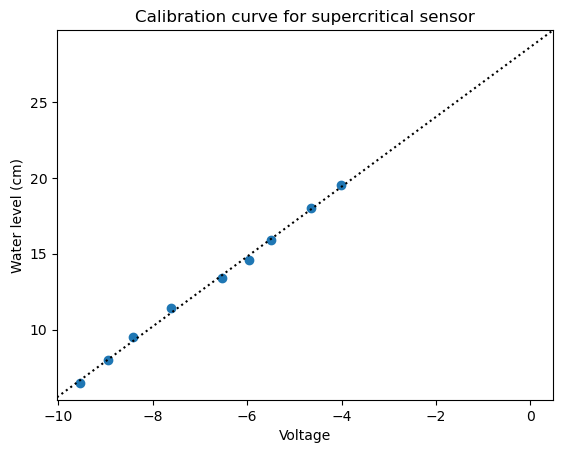

In [28]:
# calibration data
super_voltage = np.array([-9.5491, -8.9420, -8.4136, -7.6184, -6.5391, -5.9702, -5.4983, -4.6409, -4.0175])
super_height = np.array([6.5, 8, 9.5, 11.4, 13.4, 14.6, 15.9, 18, 19.5])    # cm
super_df = pd.DataFrame({'Voltage':super_voltage, 'Height':super_height})

# linear fit
super_calibration = ols('Height ~ Voltage', data=super_df).fit()
super_b0, super_b1 = super_calibration.params
print(f'b0 = {super_b0}')
print(f'b1 = {super_b1}')

# plot
plt.scatter(super_voltage, super_height)
plt.axline(xy1=(0,super_b0), slope=super_b1, color='black', linestyle=':')
plt.title('Calibration curve for supercritical sensor')
plt.xlabel('Voltage')
plt.ylabel('Water level (cm)')

### Head tank sensor calibration curve

b0 = 60.280676799317156
b1 = 2.01989757815


Text(0, 0.5, 'Water level (cm)')

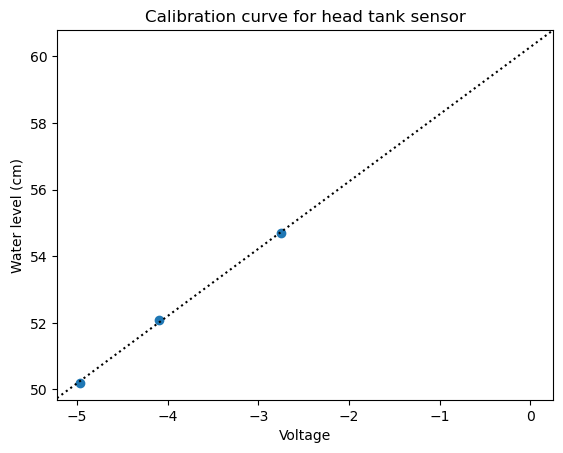

In [29]:
# calibration data
head_voltage = np.array([-2.75, -4.09, -4.97])
head_distance = np.array([9.6, 12.2, 14.1])    # cm, sensor distance from water surface
head_df = pd.DataFrame({'Voltage':head_voltage, 'Distance':head_distance})

# convert distance from water surface to water level
dist_bottom_to_vernier = 140 # cm UNCERTAIN MEASUREMENT
vernier_reading = 0.116*30.48 # ft to cm THIS WILL BE MODIFIED THROUGHOUT EXPERIMENT SO WATCH THIS WHEN PROCESSING DATA
length_vernier = 79.24 # cm UNCERTAIN MEASUREMENT

head_df['Height'] = dist_bottom_to_vernier - (length_vernier - vernier_reading) - head_df['Distance']

# linear fit
head_calibration = ols('Height ~ Voltage', data=head_df).fit()
head_b0, head_b1 = head_calibration.params
print(f'b0 = {head_b0}')
print(f'b1 = {head_b1}')

# plot
plt.scatter(head_df['Voltage'], head_df['Height'])
plt.axline(xy1=(0,head_b0), slope=head_b1, color='black', linestyle=':')
plt.title('Calibration curve for head tank sensor')
plt.xlabel('Voltage')
plt.ylabel('Water level (cm)')

#### CALCULATIONS DURING EXPERIMENT

In [25]:
voltage_subcritical = -3.6111
voltage_head = -2.9972

height_subcritical = sub_b0 + sub_b1 * voltage_subcritical
height_head = head_b0 + head_b1 * voltage_head

head_diff = height_head - height_subcritical
print(f'Subcritical height is {height_subcritical:0.2f} cm')
print(f'Head tank height is {height_head:0.2f} cm')
print(f'Head difference is {head_diff:0.2f} cm')

Subcritical height is 28.66 cm
Head tank height is 51.61 cm
Head difference is 22.95 cm


## Load data

### Read venturi meter csv file

In [36]:
venturi_file = '11-7-2025.csv'
venturi_df = pd.read_csv(venturi_file, sep=';')

display(venturi_df)

,Time stamp,PV [in H2O],State PV,SV [C],State SV,TV,State TV,QV,State QV,Current [mA],State Current
0,07.11.2025 10:07:55,"0,0256813261657953",0,"20,9836120605469",0,"0,000102725309261587",0,NaN,-1,"4,00164270401001",0
1,07.11.2025 10:07:58,"0,0254478324204683",0,"20,9836120605469",0,"0,000101791360066272",0,NaN,-1,"4,00162887573242",0
2,07.11.2025 10:08:01,"0,0253277216106653",0,"20,9840087890625",0,"0,000101310884929262",0,NaN,-1,"4,00161218643188",0
3,07.11.2025 10:08:04,"0,0249661728739738",0,"20,9840087890625",0,"9,98647010419518E-05",0,NaN,-1,"4,00159740447998",0
4,07.11.2025 10:08:06,"0,0259163565933704",0,"20,9840087890625",0,"0,000103665443020873",0,NaN,-1,"4,00165891647339",0
...,...,...,...,...,...,...,...,...,...,...,...
2504,07.11.2025 11:48:57,"0,0251846760511398",0,"21,1985778808594",0,"0,000100738725450356",0,NaN,-1,"4,00161170959473",0
2505,07.11.2025 11:48:59,"0,024498175829649",0,"21,1985778808594",0,"9,79927135631442E-05",0,NaN,-1,"4,00156831741333",0
2506,07.11.2025 11:49:02,"0,0252310559153557",0,"21,1983337402344",0,"0,00010092425509356",0,NaN,-1,"4,0016131401062",0
2507,07.11.2025 11:49:04,"0,0249232575297356",0,"21,1985778808594",0,"9,9693046649918E-05",0,NaN,-1,"4,00163698196411",0


### Read ADV data file

In [46]:
from datetime import datetime

adv_file = 'hre_adv20251107102548.dat'
adv_data = pd.read_csv(adv_file, sep='\s+', header=None)
start_time = datetime(2025, 11, 7, 10, 25, 48)
end_time = datetime(2025, 11, 7, 11, 50, 5)

time_diff = (end_time - start_time).total_seconds()

freq = 20 # Hz

display(adv_data)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,53,11,0.079,-0.680,-0.070,-0.056,53,67,21,58,15.4,15.7,10.9,17.2,95,96,83,95
1,54,11,0.047,-0.680,-0.057,-0.047,54,73,23,54,15.6,16.4,11.7,16.6,93,96,85,93
2,55,11,0.017,-0.687,-0.021,-0.012,72,78,31,76,18.1,17.0,14.3,19.6,95,95,88,95
3,56,11,0.075,-0.664,-0.030,-0.027,75,72,23,57,18.4,16.3,11.7,17.1,92,93,83,91
4,57,11,0.083,-0.675,0.017,0.036,71,67,21,46,17.9,15.7,10.9,15.2,95,95,84,91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101143,101196,11,1.063,-1.030,0.145,-0.129,131,153,128,132,23.3,22.9,26.6,24.3,50,0,50,0
101144,101197,11,0.103,1.187,-0.175,0.099,131,153,128,132,23.3,22.9,26.6,24.3,50,24,70,70
101145,101198,11,-0.417,1.175,-0.315,0.027,131,153,128,132,23.3,22.9,26.6,24.3,0,35,70,50
101146,101199,11,-0.569,2.094,-0.284,-0.148,131,153,128,132,23.3,22.9,26.6,24.3,0,24,50,50


### Read height sensor csv files

In [32]:
import glob

csv_files = sorted(glob.glob('*sensor_data.csv'))
dfs = []

for file_name in csv_files:
    try:
        df = pd.read_csv(file_name)
        dfs.append(df)
        print(f"Successfully read: {file_name}")
    except Exception as e:
        print(f"Error reading {file_name}: {e}")

V_ai0 = np.empty(len(csv_files))
V_ai1 = np.empty(len(csv_files))
V_ai2 = np.empty(len(csv_files))

for i, df in enumerate(dfs):
    V_ai0[i] = df['V_ai0'].mean()
    V_ai1[i] = df['V_ai1'].mean()
    V_ai2[i] = df['V_ai2'].mean()

sensor_data = pd.DataFrame({'V_ai0': V_ai0, 'V_ai1': V_ai1, 'V_ai2': V_ai2}) # note that trial indices are one less than the ones I wrote in the notebook

Successfully read: 2025-11-05_10-59-57_sensor_data.csv
Successfully read: 2025-11-07_09-57-18_sensor_data.csv
Successfully read: 2025-11-07_10-27-32_sensor_data.csv
Successfully read: 2025-11-07_11-00-28_sensor_data.csv
Successfully read: 2025-11-07_11-04-04_sensor_data.csv
Successfully read: 2025-11-07_11-09-05_sensor_data.csv
Successfully read: 2025-11-07_11-14-54_sensor_data.csv
Successfully read: 2025-11-07_11-18-04_sensor_data.csv
Successfully read: 2025-11-07_11-22-26_sensor_data.csv
Successfully read: 2025-11-07_11-32-52_sensor_data.csv
Successfully read: 2025-11-07_11-35-43_sensor_data.csv
Successfully read: 2025-11-07_11-38-18_sensor_data.csv


### Convert voltages to water heights

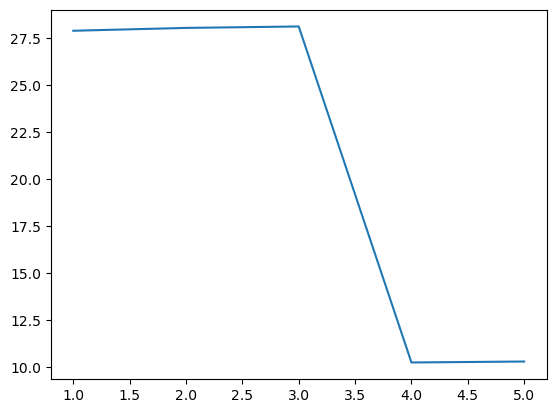

In [20]:
sensor_data['Supercritical Height (cm)'] = super_b0 + super_b1 * sensor_data['V_ai1'] # DOUBLE CHECK IF YOU MATCHED THESE CORRECTLY

plt.plot(sensor_data['Supercritical Height (cm)'])


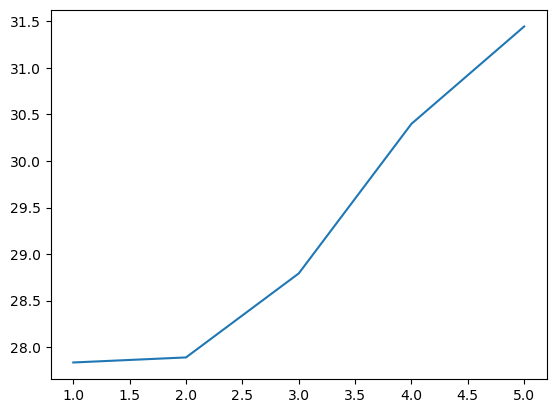

In [21]:
sensor_data['Subcritical Height (cm)'] = sub_b0 + sub_b1 * sensor_data['V_ai0']

plt.plot(sensor_data['Subcritical Height (cm)'])

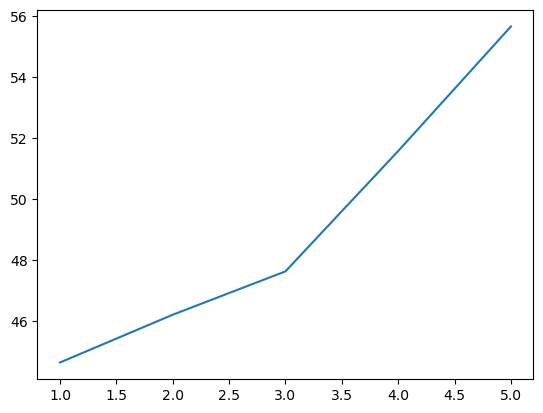

In [22]:
sensor_data['Head Tank Height (cm)'] = head_b0 + head_b1 * sensor_data['V_ai2']

plt.plot(sensor_data['Head Tank Height (cm)'])

### Plot the curves together

Text(0, 0.5, 'Water level (cm)')

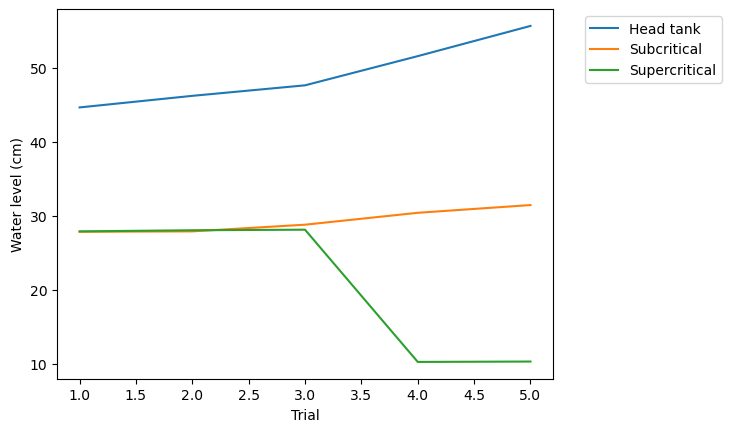

In [23]:
plt.plot(sensor_data['Head Tank Height (cm)'])
plt.plot(sensor_data['Subcritical Height (cm)'])
plt.plot(sensor_data['Supercritical Height (cm)'])


plt.legend(['Head tank', 'Subcritical', 'Supercritical'], bbox_to_anchor=(1.05, 1))
plt.xlabel('Trial')
plt.ylabel('Water level (cm)')

## Stage discharge curve

### Calculate discharge

In [24]:
sensor_data['Delta P'] = np.array([76, 84, 93, 103, 112.5]) # from venturi meter

sensor_data['Q (m3/s)'] = 0.1753*(sensor_data['Delta P']/75.36)**(1/2)

### Calculate head difference

In [25]:
sensor_data['Head diff (cm)'] = sensor_data['Head Tank Height (cm)'] - sensor_data['Subcritical Height (cm)']

### Graph stage vs discharge 

In [26]:
import seaborn as sns

,V_ai0,V_ai1,V_ai2,Supercritical Height (cm),Subcritical Height (cm),Head Tank Height (cm),Delta P,Q (m3/s),Head diff (cm)
1,-3.973797,-0.315042,-7.401165,27.889185,27.835055,44.635402,76.0,0.176043,16.800347
2,-3.949961,-0.249274,-6.626229,28.040438,27.889235,46.200694,84.0,0.185076,18.311459
3,-3.552951,-0.216199,-5.922805,28.116504,28.791605,47.621537,93.0,0.194739,18.829932
4,-2.845716,-7.984570,-3.970188,10.250702,30.399090,51.565623,103.0,0.204942,21.166533
5,-2.385560,-7.962322,-1.949319,10.301868,31.444988,55.647572,112.5,0.214184,24.202584


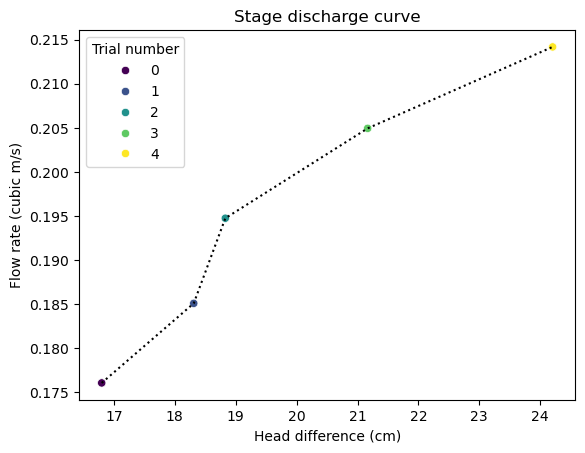

In [27]:
sns.scatterplot(x='Head diff (cm)', y='Q (m3/s)', hue=np.arange(0, len(sensor_data)), data=sensor_data, palette='viridis')
plt.plot(sensor_data['Head diff (cm)'], sensor_data['Q (m3/s)'], color='black', linestyle=':')
#sns.lineplot(x='Head diff (cm)', y='Delta P', data=sensor_data)
plt.xlabel('Head difference (cm)')
plt.ylabel('Flow rate (cubic m/s)')
plt.legend(title='Trial number')
plt.title('Stage discharge curve')

display(sensor_data)